# Análise Visual
Notebook para análise visual dos dados extraídos pelas rotinas em `./source/` armazenados em `./output/`

## Bibliotecas Utilizadas

In [4]:
import pandas as pd
import matplotlib.pyplot as ax
import json

## Convertendo dados
Convertendo o output das rotinas anteriores em `pd.DataFrame` e calculando o número do mês da observação

In [17]:
with open("../output/analise.json", "r") as fp:
    dict_analise = json.load(fp)

df = pd.DataFrame.from_dict(dict_analise).T

qtd_linhas = len(df)
numero_mes = list(range(0, qtd_linhas * 4, 4))
df["mes"] = numero_mes

df

,#arestas,#arestas_CN,#arestas_US,#asn,#asn_CN,#asn_US,#as_fronteira_CN,#as_fronteira_US,#direct_connections,#componentes_conexas,#componentes_conexas_sem_CN-US,#componentes_conexas_sem_CN,#componentes_conexas_sem_US,mes
rib.20160101.0000.pkl,125155,882,52440,53019,324,16364,50,70,156,1,15,22,1529,0
rib.20160501.0000.pkl,131741,991,53820,54258,352,16527,52,71,168,1,17,22,1526,4
rib.20160901.0000.pkl,136382,1116,55348,55385,369,16641,56,71,182,1,15,23,1523,8
rib.20170101.0000.pkl,139267,1156,56478,56472,364,16734,59,78,198,1,19,23,1538,12
rib.20170501.0000.pkl,141792,1154,57756,57714,379,16888,63,78,203,1,18,16,1601,16
rib.20170901.0000.pkl,143745,1212,57577,58990,384,16997,63,75,201,1,16,16,1658,20
rib.20180101.0000.pkl,147528,1268,58569,60178,400,17112,61,79,206,1,16,18,1660,24
rib.20180501.0000.pkl,148006,1328,58515,61474,415,17217,65,81,213,1,17,27,1736,28
rib.20180901.0000.pkl,147612,1370,58128,62478,439,17276,67,80,211,1,19,24,1738,32
rib.20190101.0000.pkl,150304,1387,58415,63524,440,17372,71,81,214,1,17,23,1729,36


## Tratando métricas
Criando novas métricas como análises percentuais

In [62]:
df["%as_fronteira_CN"] = df["#as_fronteira_CN"] / df["#asn_CN"] * 100
df["%as_fronteira_US"] = df["#as_fronteira_US"] / df["#asn_US"] * 100

## Plots

In [78]:
def plot(ax: ax.Axes, x: str, y: List[str], title: str, cores: List[str]) -> None:
    ax.set_title(title)
    for metrica, cor in zip(y, cores):
        ax.plot(df[x], df[metrica], label=metrica, c=cor)

    ax.set_ylim(0, None)
    ax.set_xlabel("mes")
    ax.legend()
    ax.grid()

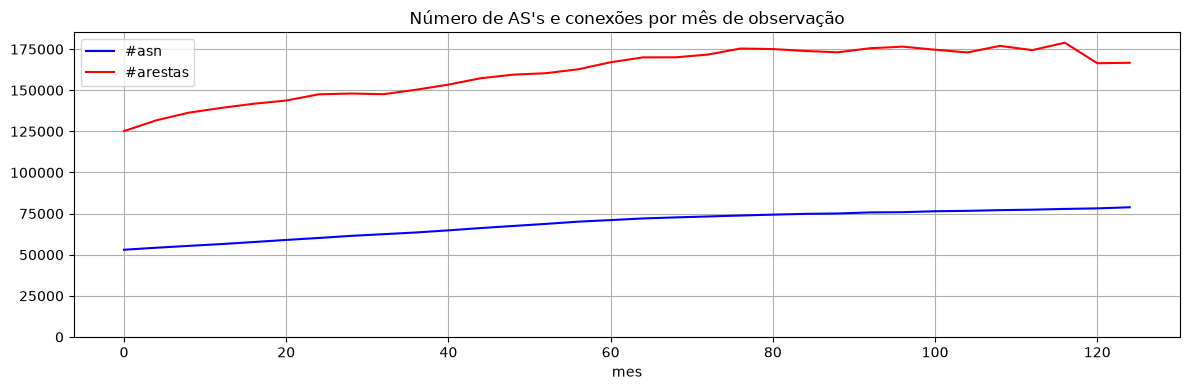

In [79]:
fig = plt.figure(figsize=(12, 4))
plot(plt.gca(), "mes", ["#asn", "#arestas"], "Número de AS's e conexões por mês de observação", ['b', 'r'])
plt.tight_layout()
plt.show()

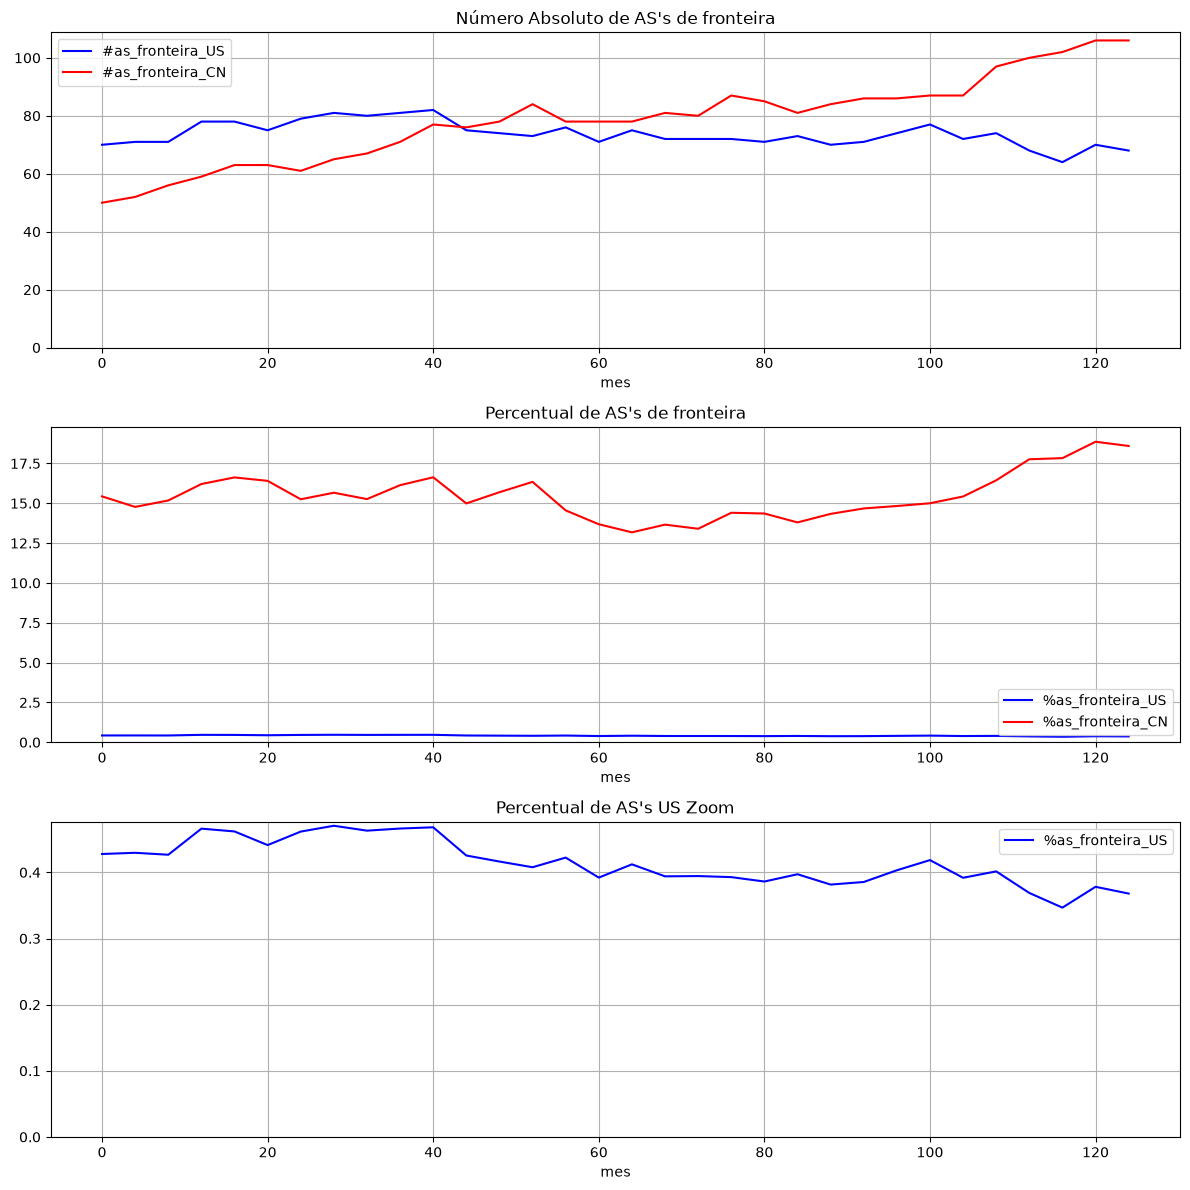

In [80]:
fig, axs = plt.subplots(3, 1, figsize=(12, 12))
plot(axs[0], "mes", ["#as_fronteira_US", "#as_fronteira_CN"], "Número Absoluto de AS's de fronteira", ['b', 'r'])
plot(axs[1], "mes", ["%as_fronteira_US", "%as_fronteira_CN"], "Percentual de AS's de fronteira", ['b', 'r'])
plot(axs[2], "mes", ["%as_fronteira_US"], "Percentual de AS's US Zoom", ['b'])
plt.tight_layout()
plt.show()